# Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np

In [4]:
!pip install kaggle


In [5]:
#Configure the path to kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
#Dataset fetching from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/sentiment140


In [7]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
sentiment140.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
#Extract zip file
from zipfile import ZipFile
df='/content/sentiment140.zip'

with ZipFile(df,'r') as zip:
  zip.extractall()
  print('Zipfile extracted')


Zipfile extracted


In [9]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [10]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [12]:
df=pd.read_csv('/content/training.1600000.processed.noemoticon.csv',encoding='latin-1')

In [13]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [14]:
df.shape

(1599999, 6)

In [15]:
data_fields=['Target','id','date','flag','user','text']
df.columns=data_fields

In [16]:
df.head()

,Target,id,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [17]:
df.isnull().sum()

,0
Target,0
id,0
date,0
flag,0
user,0
text,0


In [18]:
#Distribution of Targets
df['Target'].value_counts()

,count
Target,
4,800000
0,799999


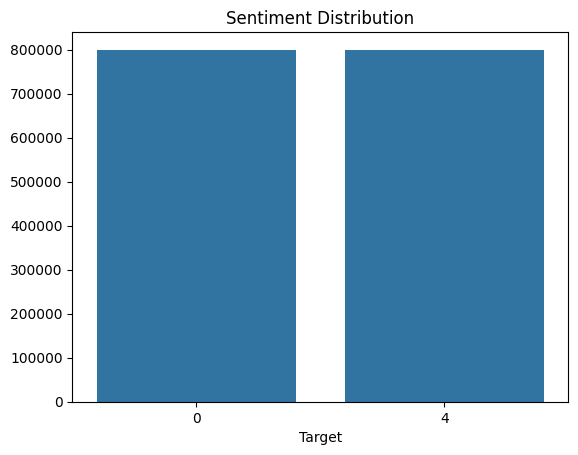

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

label_counts = df['Target'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Sentiment Distribution")
plt.show()

# The sentiment is presented as 4 as positive and 0 as negative and 2 is a neutral sentiment

# Replace
we are going to replace the 4 to 1 for a more common way of label encoding in data science

In [21]:
df.replace({'Target':{4:1}},inplace=True)

In [22]:
df['Target'].value_counts(normalize=True)

,proportion
Target,
1,0.5
0,0.5


# Machine Learning Understanding

1.   Positive Sentiment -"1"
2.   Negative Sentiment -"0"




# Data Preprocessing in NLP

In [23]:
#Stemming using the PorterStemmer-Truncation to its root words
ps=PorterStemmer()

In [24]:
def stemming(content):
  stemmed_content=re.sub('[^a-zA-Z]',' ',content)
  stemmed_content=stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[ps.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content=' '.join(stemmed_content)
  return stemmed_content

In [25]:
#Apply the function for the steps implementation
df['stemmed_content']=df['text'].apply(stemming)

In [26]:
df.drop(['id','date','flag','user','text'],axis=1,inplace=True)

In [27]:
df.head()

,Target,stemmed_content
0,0,upset updat facebook text might cri result sch...
1,0,kenichan dive mani time ball manag save rest g...
2,0,whole bodi feel itchi like fire
3,0,nationwideclass behav mad see
4,0,kwesidei whole crew


In [28]:
#separating the dataframe
x=df['stemmed_content'].values
y=df['Target'].values

In [29]:
print(x)

['upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound'
 'whole bodi feel itchi like fire' ... 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


In [30]:
print(y)

[0 0 0 ... 1 1 1]


# Implementation Of TF-IDF Vectorizer


In [31]:
#Train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)
#The stratify=y ensures that the model does not learn from more positive or more  negative but learns from both targets evenly

In [32]:
print(x.shape,x_train.shape,x_test.shape)

(1599999,) (1279999,) (320000,)


In [33]:
tfidf=TfidfVectorizer()
#This is word vector representation as a computer does not understand text
#This is done in terms of term frequency-inverse document frequency

In [34]:
x_train=tfidf.fit_transform(x_train)
x_test=tfidf.transform(x_test)

In [35]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453002 stored elements and shape (1279999, 461471)>
  Coords	Values
  (0, 436655)	0.27247657460069113
  (0, 354566)	0.358082129508793
  (0, 185125)	0.5296934860731303
  (0, 109298)	0.37470892870977707
  (0, 234920)	0.4196620311217523
  (0, 443035)	0.44770025018080273
  (1, 166826)	0.3977368489124923
  (1, 19762)	0.25286013616648123
  (1, 119689)	0.4309123985667578
  (1, 152015)	0.49196931362728563
  (1, 319721)	0.3128279791558143
  (1, 86730)	0.33015139495167095
  (1, 172343)	0.3785321144028949
  (2, 326288)	0.5853283798404598
  (2, 220710)	0.2626149875630722
  (2, 279017)	0.28499749936226054
  (2, 445635)	0.2356370052189603
  (2, 412554)	0.28961919890983545
  (2, 124728)	0.3317593891539697
  (2, 117914)	0.39861155079647814
  (2, 146003)	0.22130486737209085
  (2, 93826)	0.22330494345030885
  (3, 93826)	0.46202690964703447
  (3, 331805)	0.4656145237310222
  (3, 46285)	0.6887696820070169
  :	:
  (1279996, 13878)	0.43588823915

In [36]:
print(x_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289342 stored elements and shape (320000, 461471)>
  Coords	Values
  (0, 63768)	0.26422682589785035
  (0, 75261)	0.26552138110472423
  (0, 127038)	0.2730995033465573
  (0, 219133)	0.3295455088887744
  (0, 320624)	0.5238287544743887
  (0, 355868)	0.22363572756759686
  (0, 371332)	0.3972681545090477
  (0, 375613)	0.24658637821166524
  (0, 382367)	0.2541115193458825
  (0, 414033)	0.2624690535388268
  (1, 6452)	0.3061987253241848
  (1, 15098)	0.21044041574811612
  (1, 145408)	0.5774478727480551
  (1, 217431)	0.40260807391422926
  (1, 256686)	0.2861349119561766
  (1, 348128)	0.4737202797635419
  (1, 366259)	0.24522188688615762
  (2, 79341)	0.34512546063620464
  (2, 88422)	0.33529803711277506
  (2, 107866)	0.36857211925047617
  (2, 124443)	0.2729825984376057
  (2, 258609)	0.3072614985829275
  (2, 375890)	0.3020734075258265
  (2, 407333)	0.27060796399382786
  (2, 418804)	0.33257344872506
  :	:
  (319995, 193560)	0.373116119782695


# Model Building

The Dataset is trained on:

1.Logistic Regression

2.Support Vector Mahines(SVM)

# Logistic Regression

In [54]:
model_lr=LogisticRegression(max_iter=1000)

In [55]:
model_lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [56]:
x_train_prediction=model_lr.predict(x_train)

In [57]:
#Evaluation of how well the model learnt
training_accuracy=accuracy_score(y_train,x_train_prediction)

In [59]:
print(f'Training Accuracy:{training_accuracy}')

Training Accuracy:0.801063125830567


<Axes: >

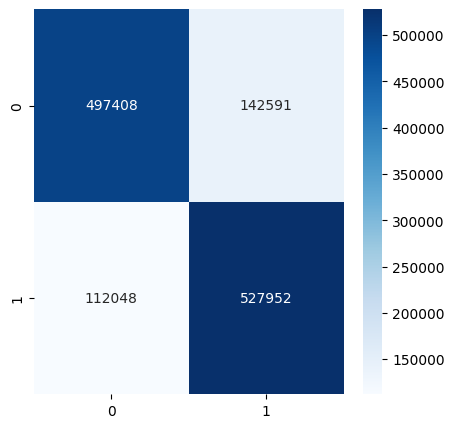

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_train,x_train_prediction),annot=True,fmt='d',cmap='Blues')


In [43]:
#Accuracy score for test data
x_test_prediction=model.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)
print(f"Accuracy score for test data:{test_data_accuracy}")

Accuracy score for test data:0.7771625


# Support Vector Machines(SVM)

In [44]:
from sklearn.svm import LinearSVC
model=LinearSVC(max_iter=1000)

In [45]:
model.fit(x_train,y_train)

LinearSVC()

In [46]:
svm_x_train_prediction=model.predict(x_train)

In [47]:
svm_training_accuracy=accuracy_score(y_train,svm_x_train_prediction)

In [48]:
print(f'Training Accuracy:{svm_training_accuracy}')

Training Accuracy:0.8623991112493057


<Axes: >

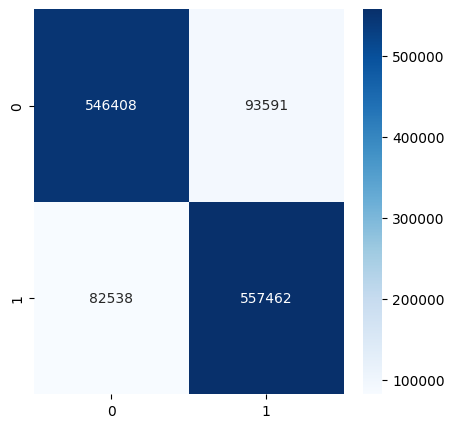

In [49]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_train,svm_x_train_prediction),annot=True,fmt='d',cmap='Blues')

In [50]:
#Accuracy for the svm test data
svm_x_test_prediction=model.predict(x_test)
svm_test_data_accuracy=accuracy_score(svm_x_test_prediction,y_test)
print(f"Accuracy score for test data:{svm_test_data_accuracy}")

Accuracy score for test data:0.769390625


In [60]:
#Saving logistic regression model
import pickle
pickle.dump(model_lr, open("logisticRegressionmodel.pickle.dat", "wb"))

In [61]:
lr_loaded_model = pickle.load(open("logisticRegressionmodel.pickle.dat", "rb"))
lr_loaded_model

LogisticRegression(max_iter=1000)